# LDA Implementation — Assignment 3

Implement Linear Discriminant Analysis from scratch without using a built-in LDA implementation.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris


## 1. Class-wise Means and Overall Mean

In [11]:
def compute_means(X, y):
    overall_mean = np.mean(X, axis=0)
    class_means = {}

    for cls in np.unique(y):
        class_means[cls] = np.mean(X[y == cls], axis=0)

    return class_means, overall_mean


## 2. Within-Class Scatter Matrix

$S_W$ measures the spread of samples around their class means.

In [12]:
def compute_within_class_scatter(X, y, class_means):
    n_features = X.shape[1]
    S_W = np.zeros((n_features, n_features))

    for cls, mean_vec in class_means.items():
        X_cls = X[y == cls]
        centered = X_cls - mean_vec
        S_W += centered.T @ centered

    return S_W


## 3. Between-Class Scatter Matrix

$S_B$ measures the separation of class means from the overall mean.

In [13]:
def compute_between_class_scatter(X, y, class_means, overall_mean):
    n_features = X.shape[1]
    S_B = np.zeros((n_features, n_features))

    for cls, mean_vec in class_means.items():
        n_cls = np.sum(y == cls)
        diff = (mean_vec - overall_mean).reshape(-1, 1)
        S_B += n_cls * (diff @ diff.T)

    return S_B


## 4. Eigenvalue Problem

LDA finds directions that maximize between-class separation relative to within-class variation. The eigenvalues measure the discriminating power of the directions, and the eigenvectors provide the projection directions.

In [14]:
def solve_eigenvalue_problem(S_W, S_B):
    matrix = np.linalg.solve(S_W, S_B)
    eigenvalues, eigenvectors = np.linalg.eig(matrix)

    return eigenvalues.real, eigenvectors.real


## 5. Select Top k Discriminant Vectors

In [15]:
def select_top_k_components(eigenvalues, eigenvectors, k):
    max_components = len(np.unique(y_iris)) - 1
    if k < 1 or k > max_components:
        raise ValueError(f"k must be between 1 and {max_components}")

    indices = np.argsort(eigenvalues)[::-1][:k]
    return eigenvectors[:, indices]


## 6. Project Data

In [16]:
def project_data(X, W, overall_mean):
    return (X - overall_mean) @ W


## 7. Complete LDA Implementation

In [17]:
def lda_from_scratch(X, y, n_components):
    class_means, overall_mean = compute_means(X, y)
    S_W = compute_within_class_scatter(X, y, class_means)
    S_B = compute_between_class_scatter(X, y, class_means, overall_mean)
    eigenvalues, eigenvectors = solve_eigenvalue_problem(S_W, S_B)

    max_components = len(class_means) - 1
    if n_components < 1 or n_components > max_components:
        raise ValueError(f"n_components must be between 1 and {max_components}")

    indices = np.argsort(eigenvalues)[::-1][:n_components]
    W = eigenvectors[:, indices]
    X_projected = project_data(X, W, overall_mean)

    return X_projected, W, S_W, S_B, eigenvalues


## Apply LDA to Iris Dataset

In [18]:
iris = load_iris()
X = iris.data
y = iris.target

X_lda, W, S_W, S_B, eigenvalues = lda_from_scratch(X, y, n_components=2)

print("Original shape:", X.shape)
print("Reduced shape:", X_lda.shape)
print("Eigenvalues:", eigenvalues)
print("Projection matrix shape:", W.shape)


Original shape: (150, 4)
Reduced shape: (150, 2)
Eigenvalues: [3.21919292e+01 2.85391043e-01 6.95358376e-15 2.38214688e-15]
Projection matrix shape: (4, 2)


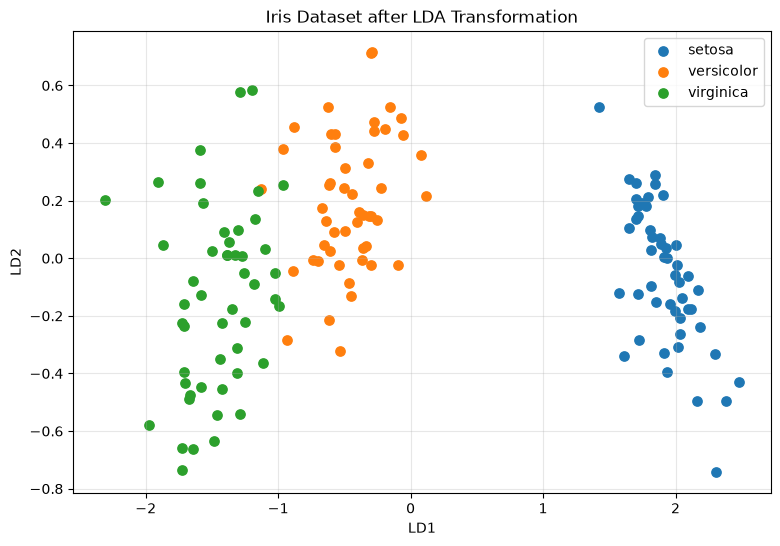

In [19]:
plt.figure(figsize=(9, 6))

for cls, name in enumerate(iris.target_names):
    plt.scatter(
        X_lda[y == cls, 0],
        X_lda[y == cls, 1],
        label=name,
        s=45
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.title("Iris Dataset after LDA Transformation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Explanation

LDA maximizes class separability by finding projection directions that increase between-class scatter while reducing within-class scatter. The Iris dataset is reduced from four features to two discriminant dimensions.